In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
traffic = pd.read_csv("./data/dft_traffic_counts_raw_counts.csv.gz")
print(traffic.shape)
traffic.head()

(4815504, 35)


,Count_point_id,Direction_of_travel,Year,Count_date,hour,Region_id,Region_name,Region_ons_code,Local_authority_id,Local_authority_name,...,Buses_and_coaches,LGVs,HGVs_2_rigid_axle,HGVs_3_rigid_axle,HGVs_4_or_more_rigid_axle,HGVs_3_or_4_articulated_axle,HGVs_5_articulated_axle,HGVs_6_articulated_axle,All_HGVs,All_motor_vehicles
0,749,E,2014,2014-06-25 00:00:00,7,3,Scotland,S92000003,39,East Ayrshire,...,5.0,31,15.0,4.0,4.0,4.0,13,12.0,52.0,935.0
1,749,E,2014,2014-06-25 00:00:00,8,3,Scotland,S92000003,39,East Ayrshire,...,7.0,103,29.0,3.0,2.0,7.0,18,20.0,79.0,1102.0
2,749,E,2014,2014-06-25 00:00:00,9,3,Scotland,S92000003,39,East Ayrshire,...,14.0,88,21.0,3.0,5.0,9.0,17,19.0,74.0,773.0
3,749,E,2014,2014-06-25 00:00:00,10,3,Scotland,S92000003,39,East Ayrshire,...,8.0,90,31.0,6.0,10.0,7.0,18,17.0,89.0,778.0
4,749,E,2014,2014-06-25 00:00:00,11,3,Scotland,S92000003,39,East Ayrshire,...,18.0,75,38.0,2.0,2.0,3.0,16,24.0,85.0,875.0


In [3]:

traffic.head(1).transpose()

,0
Count_point_id,749
Direction_of_travel,E
Year,2014
Count_date,2014-06-25 00:00:00
hour,7
Region_id,3
Region_name,Scotland
Region_ons_code,S92000003
Local_authority_id,39
Local_authority_name,East Ayrshire


In [4]:

traffic.isnull().sum()

Count_point_id                        0
Direction_of_travel                   0
Year                                  0
Count_date                            0
hour                                  0
Region_id                             0
Region_name                           0
Region_ons_code                       0
Local_authority_id                    0
Local_authority_name                  0
Local_authority_code                  0
Road_name                             0
Road_category                         0
Road_type                             0
Start_junction_road_name        2634972
End_junction_road_name          2634912
Easting                               0
Northing                              0
Latitude                              0
Longitude                             0
Link_length_km                  2632824
Link_length_miles               2632824
Pedal_cycles                          0
Two_wheeled_motor_vehicles            0
Cars_and_taxis                        1


In [5]:
len(traffic[["Count_point_id", "Year", "Count_date", "hour"]].drop_duplicates())

2435120

In [6]:
len(traffic[["Count_point_id", "Year", "Count_date", "hour", "Direction_of_travel"]].drop_duplicates())

4815480

Looks like it should be one row per:

date
hour
location
direction of travel

Let's find the exceptions:

In [7]:
duplicate_groups = (
    traffic
    .groupby(["Count_point_id", "Year", "Count_date", "hour", "Direction_of_travel"])
    .size()
    .loc[lambda x: x > 1]
)

duplicate_groups

Count_point_id  Year  Count_date           hour  Direction_of_travel
7845            2014  2014-09-03 00:00:00  7     W                      2
                                           8     W                      2
                                           9     W                      2
                                           10    W                      2
                                           11    W                      2
                                           12    W                      2
                                           13    W                      2
                                           14    W                      2
                                           15    W                      2
                                           16    W                      2
                                           17    W                      2
                                           18    W                      2
77043           2003  2003-06-18 00:00:00  

In [8]:
example_dupes = (
    traffic[
        (traffic["Count_point_id"] == 7845)
        & (traffic["Count_date"] == "2014-09-03 00:00:00")
        & (traffic["hour"] == 7)
        & (traffic["Direction_of_travel"] == "W")
    ]
)

example_dupes

,Count_point_id,Direction_of_travel,Year,Count_date,hour,Region_id,Region_name,Region_ons_code,Local_authority_id,Local_authority_name,...,Buses_and_coaches,LGVs,HGVs_2_rigid_axle,HGVs_3_rigid_axle,HGVs_4_or_more_rigid_axle,HGVs_3_or_4_articulated_axle,HGVs_5_articulated_axle,HGVs_6_articulated_axle,All_HGVs,All_motor_vehicles
24372,7845,W,2014,2014-09-03 00:00:00,7,10,West Midlands,E12000005,151,Solihull,...,7.0,185,30.0,5.0,5.0,6.0,2,10.0,58.0,1826.0
24384,7845,W,2014,2014-09-03 00:00:00,7,10,West Midlands,E12000005,151,Solihull,...,9.0,168,29.0,6.0,1.0,1.0,4,13.0,54.0,1354.0


In [9]:
(
    example_dupes
    .eq(example_dupes.shift(-1))
    .iloc[0]
    .loc[lambda x: x == False]
)


Two_wheeled_motor_vehicles      False
Cars_and_taxis                  False
Buses_and_coaches               False
LGVs                            False
HGVs_2_rigid_axle               False
HGVs_3_rigid_axle               False
HGVs_4_or_more_rigid_axle       False
HGVs_3_or_4_articulated_axle    False
HGVs_5_articulated_axle         False
HGVs_6_articulated_axle         False
All_HGVs                        False
All_motor_vehicles              False
Name: 24372, dtype: bool

In [10]:

traffic.columns

Index(['Count_point_id', 'Direction_of_travel', 'Year', 'Count_date', 'hour',
       'Region_id', 'Region_name', 'Region_ons_code', 'Local_authority_id',
       'Local_authority_name', 'Local_authority_code', 'Road_name',
       'Road_category', 'Road_type', 'Start_junction_road_name',
       'End_junction_road_name', 'Easting', 'Northing', 'Latitude',
       'Longitude', 'Link_length_km', 'Link_length_miles', 'Pedal_cycles',
       'Two_wheeled_motor_vehicles', 'Cars_and_taxis', 'Buses_and_coaches',
       'LGVs', 'HGVs_2_rigid_axle', 'HGVs_3_rigid_axle',
       'HGVs_4_or_more_rigid_axle', 'HGVs_3_or_4_articulated_axle',
       'HGVs_5_articulated_axle', 'HGVs_6_articulated_axle', 'All_HGVs',
       'All_motor_vehicles'],
      dtype='object')

In [11]:

print(traffic["Link_length_km"].min(),
      traffic["Link_length_miles"].min())

0.1 0.06


In [12]:
TEXT_PLACEHOLDER = "PLACEHOLDER"
NUMBER_PLACEHOLDER = -9999

group_cols = [
    'Count_point_id', 'Direction_of_travel', 'Year', 'Count_date', 'hour',
    'Region_id', 'Region_name', 'Region_ons_code', 'Local_authority_id',
    'Local_authority_name', 'Local_authority_code', 'Road_name',
    'Road_category', 'Road_type', 'Start_junction_road_name',
    'End_junction_road_name', 'Easting', 'Northing', 'Latitude',
    'Longitude', 'Link_length_km', 'Link_length_miles'
]

traffic_deduped = (
    traffic
    .assign(
        Start_junction_road_name = lambda df_: df_["Start_junction_road_name"].fillna(TEXT_PLACEHOLDER),
        End_junction_road_name = lambda df_: df_["End_junction_road_name"].fillna(TEXT_PLACEHOLDER),
        Link_length_km = lambda df_: df_["Link_length_km"].fillna(NUMBER_PLACEHOLDER),
        Link_length_miles = lambda df_: df_["Link_length_miles"].fillna(NUMBER_PLACEHOLDER)
    )
    .groupby(group_cols)
    .mean(numeric_only=True)
    .reset_index()
    .assign(
        Start_junction_road_name = lambda df_: df_["Start_junction_road_name"].replace(TEXT_PLACEHOLDER, np.nan),
        End_junction_road_name = lambda df_: df_["End_junction_road_name"].replace(TEXT_PLACEHOLDER, np.nan),
        Link_length_km = lambda df_: df_["Link_length_km"].replace(NUMBER_PLACEHOLDER, np.nan),
        Link_length_miles = lambda df_: df_["Link_length_miles"].replace(NUMBER_PLACEHOLDER, np.nan)
    )
)

print(traffic.shape, traffic_deduped.shape)
traffic_deduped.head()

(4815504, 35) (4815480, 35)


,Count_point_id,Direction_of_travel,Year,Count_date,hour,Region_id,Region_name,Region_ons_code,Local_authority_id,Local_authority_name,...,Buses_and_coaches,LGVs,HGVs_2_rigid_axle,HGVs_3_rigid_axle,HGVs_4_or_more_rigid_axle,HGVs_3_or_4_articulated_axle,HGVs_5_articulated_axle,HGVs_6_articulated_axle,All_HGVs,All_motor_vehicles
0,51,E,2020,2020-10-02 00:00:00,7,1,South West,E12000009,1,Isles of Scilly,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
1,51,E,2020,2020-10-02 00:00:00,8,1,South West,E12000009,1,Isles of Scilly,...,0.0,15.0,3.0,0.0,0.0,0.0,0.0,0.0,3.0,44.0
2,51,E,2020,2020-10-02 00:00:00,9,1,South West,E12000009,1,Isles of Scilly,...,0.0,17.0,3.0,0.0,0.0,0.0,0.0,0.0,3.0,36.0
3,51,E,2020,2020-10-02 00:00:00,10,1,South West,E12000009,1,Isles of Scilly,...,0.0,19.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,49.0
4,51,E,2020,2020-10-02 00:00:00,11,1,South West,E12000009,1,Isles of Scilly,...,0.0,18.0,4.0,0.0,0.0,0.0,0.0,0.0,4.0,48.0



# Coverage

In [13]:
traffic["Count_date"] = pd.to_datetime(traffic["Count_date"], format="%Y-%m-%d %H:%M:%S")

In [14]:
traffic["Count_date"].agg(["min", "max"])

min   2000-03-17
max   2022-11-02
Name: Count_date, dtype: datetime64[ns]

In [15]:
coverage_by_point = (
    traffic
    .groupby("Count_point_id")
    ["Count_date"]
    .agg(["min", "max"])
    .assign(coverage_years = lambda x: (x["max"] - x["min"]).dt.days / 365)
    .sort_values("coverage_years", ascending=False)
)

coverage_by_point

,min,max,coverage_years
Count_point_id,,,
36583,2000-03-24,2022-10-21,22.591781
57775,2000-03-22,2022-10-13,22.575342
60024,2000-03-21,2022-10-11,22.572603
70222,2000-03-17,2022-10-05,22.567123
38544,2000-03-17,2022-10-03,22.561644
...,...,...,...
940862,2008-10-02,2008-10-02,0.000000
940867,2009-03-20,2009-03-20,0.000000
940868,2008-04-14,2008-04-14,0.000000


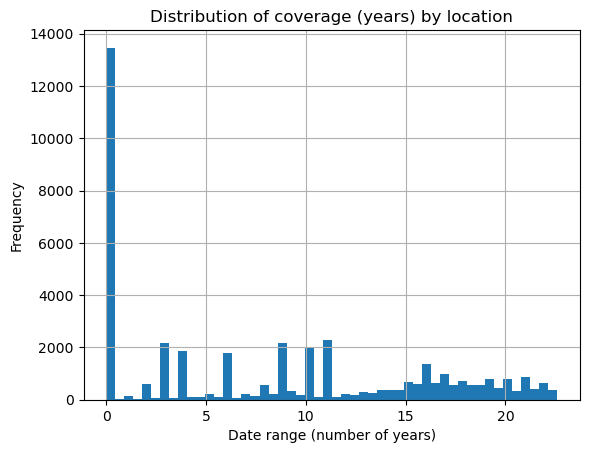

In [16]:
fig, axis = plt.subplots()

coverage_by_point["coverage_years"].hist(bins=50, ax=axis)

axis.set(
    title="Distribution of coverage (years) by location",
    xlabel="Date range (number of years)",
    ylabel="Frequency"
)

plt.show()

Lots of locations with zero. What/where are they?

In [17]:
zero_location_ids = coverage_by_point[coverage_by_point["coverage_years"] == 0].index

zero_locations = (
    traffic[traffic["Count_point_id"].isin(zero_location_ids)]
    .drop_duplicates("Count_point_id")
)

print(len(zero_locations))
zero_locations.head()

13460


,Count_point_id,Direction_of_travel,Year,Count_date,hour,Region_id,Region_name,Region_ons_code,Local_authority_id,Local_authority_name,...,Buses_and_coaches,LGVs,HGVs_2_rigid_axle,HGVs_3_rigid_axle,HGVs_4_or_more_rigid_axle,HGVs_3_or_4_articulated_axle,HGVs_5_articulated_axle,HGVs_6_articulated_axle,All_HGVs,All_motor_vehicles
15618,40868,E,2014,2014-10-06,7,3,Scotland,S92000003,35,Highland,...,0.0,31,3.0,2.0,1.0,1.0,0,5.0,12.0,90.0
34704,82007,E,2014,2014-06-24,7,3,Scotland,S92000003,48,Inverclyde,...,37.0,201,16.0,1.0,2.0,0.0,2,16.0,37.0,1647.0
35554,82008,E,2014,2014-05-16,7,3,Scotland,S92000003,48,Inverclyde,...,35.0,134,18.0,1.0,2.0,5.0,1,6.0,33.0,1449.0
37318,83012,N,2014,2014-06-24,7,3,Scotland,S92000003,3,Glasgow City,...,0.0,116,16.0,3.0,2.0,2.0,2,1.0,26.0,433.0
39033,82108,E,2014,2014-09-15,7,2,East Midlands,E12000004,2,Nottinghamshire,...,5.0,145,18.0,5.0,8.0,5.0,20,16.0,72.0,759.0


In [18]:

zero_locations["Region_name"].value_counts()

Region_name
South East                  1906
East of England             1724
South West                  1656
North West                  1571
Yorkshire and the Humber    1262
West Midlands               1256
East Midlands               1089
Scotland                     942
London                       829
North East                   713
Wales                        512
Name: count, dtype: int64

In [19]:
location_sizes = (
    traffic
    .groupby("Region_name")
    ["Count_point_id"]
    .nunique()
)

location_sizes

Region_name
East Midlands               3405
East of England             4666
London                      3329
North East                  2022
North West                  5063
Scotland                    3376
South East                  6097
South West                  4451
Wales                       2338
West Midlands               4132
Yorkshire and the Humber    3642
Name: Count_point_id, dtype: int64

In [20]:

(
    location_sizes
    .reset_index()
    .merge(
        zero_locations["Region_name"]
            .value_counts()
            .reset_index(name="count")
            .rename(columns={"index": "Region_name"}),
        on="Region_name"
    )
    .rename(columns={
        "Count_point_id": "total_points",
        "count": "number_of_zeros"
    })
    .assign(pct_zeros = lambda x: x["number_of_zeros"] / x["total_points"])
)

,Region_name,total_points,number_of_zeros,pct_zeros
0,East Midlands,3405,1089,0.319824
1,East of England,4666,1724,0.369481
2,London,3329,829,0.249024
3,North East,2022,713,0.352621
4,North West,5063,1571,0.310290
5,Scotland,3376,942,0.279028
6,South East,6097,1906,0.312613
7,South West,4451,1656,0.372051
8,Wales,2338,512,0.218991
9,West Midlands,4132,1256,0.303969



So that's 25-30% of locations with only one one count instance in all regions, which roughly equal (but noticably fewer in London, Scotland, Wales).

What about by LA?

In [21]:
la_sizes = (
    traffic
    .groupby("Local_authority_name")
    ["Count_point_id"]
    .nunique()
)

la_sizes

Local_authority_name
Aberdeen City            84
Aberdeenshire           223
Angus                    86
Argyll & Bute           112
Barking and Dagenham     48
                       ... 
Wokingham               109
Wolverhampton           172
Worcestershire          537
Wrexham                 100
York                    110
Name: Count_point_id, Length: 211, dtype: int64

In [22]:
(
    la_sizes
    .reset_index()
    .merge(
        zero_locations["Local_authority_name"]
            .value_counts()
            .reset_index(name="count")
            .rename(columns={"index": "Local_authority_name"}),
        on="Local_authority_name"
    )
    .rename(columns={"Count_point_id": "total_points", "count": "number_of_zeros"})
    .assign(pct_zeros = lambda x: x["number_of_zeros"] / x["total_points"])
    .sort_values("pct_zeros")
)

,Local_authority_name,total_points,number_of_zeros,pct_zeros
199,West Northamptonshire,83,6,0.072289
168,Southwark,119,13,0.109244
91,Islington,86,10,0.116279
125,North Northamptonshire,75,9,0.120000
30,Camden,97,12,0.123711
...,...,...,...,...
106,Luton,97,41,0.422680
44,Cumbria,585,252,0.430769
128,North Yorkshire,726,318,0.438017
120,Norfolk,1001,495,0.494505


# Gaps

In [23]:
points_and_dates = (
    traffic
    .groupby(["Count_point_id", "Count_date"])
    .size()
    .reset_index()
    .sort_values(["Count_point_id", "Count_date"])
)

points_and_dates.head()

,Count_point_id,Count_date,0
0,51,2004-05-21,24
1,51,2012-10-17,24
2,51,2020-10-02,24
3,52,2002-09-24,24
4,52,2011-10-04,24


In [24]:
num_years_by_point = (
    traffic
    .groupby("Count_point_id")
    ["Year"]
    .nunique()
    .loc[lambda x: x > 10]
    .sort_values(ascending=False)
)

num_years_by_point

Count_point_id
26010     23
46010     23
46008     23
16008     23
56047     23
          ..
943254    11
943258    11
943260    11
943262    11
942247    11
Name: Year, Length: 4959, dtype: int64

In [ ]:
fig, axis = plt.subplots()

LOCATION_ID = "26010"

(
    traffic
    .query(f"Count_point_id == {LOCATION_ID}")
    .groupby("Count_date")
    ["All_motor_vehicles"]
    .sum()
    .plot(ax=axis)
)

axis.set(
    title=f"Number of vehicles over time (location {LOCATION_ID})",
    xlabel="Date",
    ylabel="Number of vehicles (total)"
)

plt.show()

In [25]:
num_years_by_point

Count_point_id
26010     23
46010     23
46008     23
16008     23
56047     23
          ..
943254    11
943258    11
943260    11
943262    11
942247    11
Name: Year, Length: 4959, dtype: int64

In [26]:
long_count_points = num_years_by_point.index

gaps = (
    traffic
    .query("Count_point_id in @long_count_points")
    [["Count_point_id", "Year"]]
    .drop_duplicates()
    .sort_values(["Count_point_id", "Year"])
    .assign(
        prev_year= lambda x: x["Year"].shift(),
        diff= lambda x: x["Year"] - x["prev_year"]
    )
)

gaps.head(20)

,Count_point_id,Year,prev_year,diff
2702896,501,2000,NaN,NaN
2526432,501,2001,2000.0,1.0
2320148,501,2002,2001.0,1.0
2642988,501,2004,2002.0,2.0
1444969,501,2006,2004.0,2.0
528811,501,2009,2006.0,3.0
3353634,501,2010,2009.0,1.0
3028085,501,2011,2010.0,1.0
2669418,501,2012,2011.0,1.0
2977261,501,2013,2012.0,1.0


In [27]:
gaps = (
    gaps
    .assign(
        prev_id= lambda x: x["Count_point_id"].shift()
    )
    .query("diff > 1 and Count_point_id == prev_id")
)

gaps.head()

,Count_point_id,Year,prev_year,diff,prev_id
2642988,501,2004,2002.0,2.0,501.0
1444969,501,2006,2004.0,2.0,501.0
528811,501,2009,2006.0,3.0,501.0
4054701,501,2019,2017.0,2.0,501.0
4791625,501,2022,2020.0,2.0,501.0


In [28]:
gap_ids = gaps["Count_point_id"].unique()

all_time_series_raw = (
    traffic
    .query("Count_point_id in @long_count_points \
    and Count_point_id not in @gap_ids")
)

all_time_series_raw.head()

,Count_point_id,Direction_of_travel,Year,Count_date,hour,Region_id,Region_name,Region_ons_code,Local_authority_id,Local_authority_name,...,Buses_and_coaches,LGVs,HGVs_2_rigid_axle,HGVs_3_rigid_axle,HGVs_4_or_more_rigid_axle,HGVs_3_or_4_articulated_axle,HGVs_5_articulated_axle,HGVs_6_articulated_axle,All_HGVs,All_motor_vehicles
2488,931855,E,2016,2016-06-06,7,3,Scotland,S92000003,206,East Renfrewshire,...,4.0,33,1.0,0.0,0.0,0.0,0,0.0,1.0,233.0
2489,931855,E,2016,2016-06-06,8,3,Scotland,S92000003,206,East Renfrewshire,...,12.0,30,0.0,3.0,3.0,0.0,1,0.0,7.0,437.0
2490,931855,E,2016,2016-06-06,9,3,Scotland,S92000003,206,East Renfrewshire,...,4.0,21,0.0,1.0,3.0,0.0,0,1.0,5.0,250.0
2491,931855,E,2016,2016-06-06,10,3,Scotland,S92000003,206,East Renfrewshire,...,2.0,36,2.0,0.0,0.0,0.0,0,0.0,2.0,261.0
2492,931855,E,2016,2016-06-06,11,3,Scotland,S92000003,206,East Renfrewshire,...,2.0,43,1.0,2.0,1.0,0.0,0,0.0,4.0,282.0


Now let's aggregate the filtered raw data to annual counts

In [29]:
all_time_series = (
    all_time_series_raw
    .groupby(["Count_point_id", "Count_date"])
    ["All_motor_vehicles"]
    .sum()
    .reset_index()
)

print(all_time_series["Count_point_id"].nunique())

all_time_series.head()

1419


,Count_point_id,Count_date,All_motor_vehicles
0,6003,2000-03-31,87479.0
1,6003,2001-06-25,74103.0
2,6003,2002-05-21,72377.0
3,6003,2003-06-05,91505.0
4,6003,2004-06-16,90564.0


The measurements are taken on one day each year, so let's see what days of the week that's spread across.

In [30]:
(
    all_time_series_raw[["Count_date"]]
    .drop_duplicates()
    ["Count_date"]
    .dt.weekday
    .value_counts(normalize=True)
    .sort_index()
)

Count_date
0    0.186194
1    0.203293
2    0.205193
3    0.200127
4    0.205193
Name: proportion, dtype: float64

Now let's identify locations where measurements are at least taken in the same month every year.

In [31]:
same_month_time_series = (
    all_time_series
    .assign(month=lambda x: x["Count_date"].dt.month)
    .groupby("Count_point_id")
    ["month"]
    .nunique()
    .loc[lambda x: x == 1]
)

print(len(same_month_time_series))

same_month_time_series.head()

691


Count_point_id
900056    1
919150    1
930188    1
931832    1
931837    1
Name: month, dtype: int64